# Ligand Binding

This is a page about ligand binding.

In [ ]:
println("Hello, Ligand Binding!")

Hello, Ligand Binding!


Matplotlib is building the font cache; this may take a moment.


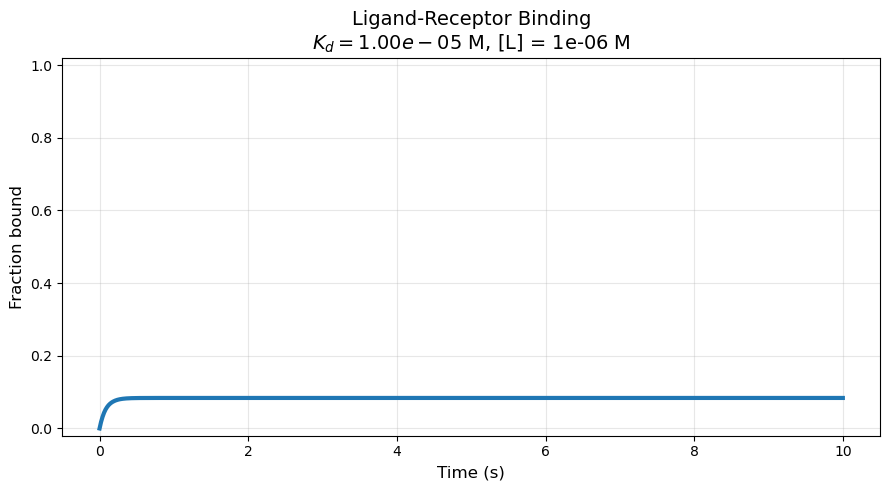


Plain-English summary:
The curve shows how quickly receptors become occupied when exposed to ligand.
Binding starts at zero and approaches an equilibrium value determined by the ligand concentration and Kd.
Here [L] ≈ Kd, so ~50% of receptors are bound at steady state.
Try changing L_init below to see saturation (high [L]) or sparse binding (low [L]).



In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.16.3
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# # Ligand-Receptor Binding Kinetics (Python)
#
# We model simple reversible binding:
#
# $$ R + L \underset{k_{-}}{\stackrel{k_{+}}{\rightleftharpoons}} RL $$
#
# - $R$: free receptor  
# - $L$: free ligand (neurotransmitter)  
# - $RL$: bound complex  
# - $k_{+}$: association rate constant  
# - $k_{-}$: dissociation rate constant  
# - $K_d = k_{-}/k_{+}$  
#
# Goal: Simulate the time course of receptor occupancy.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters (easily adjustable)
k_plus  = 1e6    # Association rate (M⁻¹ s⁻¹) – typical for diffusion-limited binding
k_minus = 10     # Dissociation rate (s⁻¹)
Kd = k_minus / k_plus                # Dissociation constant (M)
R_total = 1e-6   # Total receptor concentration (1 μM)
L_init  = 1e-6   # Initial ligand concentration (1 μM)

# Time vector
t = np.linspace(0, 10, 1000)  # 0 to 10 seconds

# Differential equation: d[RL]/dt = k+·[R]·[L] − k−·[RL]
def dRL_dt(RL, t):
    R_free = R_total - RL
    L_free = L_init - RL
    return k_plus * R_free * L_free - k_minus * RL

# Initial condition: no bound receptors
RL0 = 0.0

# Solve ODE
RL = odeint(dRL_dt, RL0, t)[:, 0]

# Fraction of receptors bound
fraction_bound = RL / R_total

# Plot
plt.figure(figsize=(9, 5))
plt.plot(t, fraction_bound, linewidth=3, color='#1f77b4')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Fraction bound', fontsize=12)
plt.title(f'Ligand-Receptor Binding\n$K_d = {Kd:.2e}$ M, [L] = {L_init:.0e} M', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

# Plain-English description for accessibility
print("""
Plain-English summary:
The curve shows how quickly receptors become occupied when exposed to ligand.
Binding starts at zero and approaches an equilibrium value determined by the ligand concentration and Kd.
Here [L] ≈ Kd, so ~50% of receptors are bound at steady state.
Try changing L_init below to see saturation (high [L]) or sparse binding (low [L]).
""")